# Experiment 4
# ML Modeling & Experiment Tracking

## Aim
To build machine learning models for Airbnb price prediction, tune their hyperparameters, compare their performance, track experiments using MLflow, and save the best-performing model.

## Objective
To develop and evaluate regression models for predicting Airbnb listing prices using the prepared merged dataset, optimize selected models using hyperparameter tuning, and track model parameters, metrics, and artifacts using MLflow.

In [ ]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

Step 4 — Import Libraries

## Import Required Libraries

The required Python libraries are imported for data manipulation, preprocessing, machine learning, hyperparameter tuning, evaluation, model serialization, and experiment tracking.

In [ ]:
import os
import warnings
import pickle

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# MLflow
import mlflow
import mlflow.sklearn

print("All libraries imported successfully.")

All libraries imported successfully.


Step 5 — Mount Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Step 6 — Define Project Paths

ADS-Airbnb-Project/
└── datasets/
    └── processed/
        └── merged_dataset.csv

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/ADS-Airbnb-Project"

DATA_PATH = os.path.join(
    PROJECT_PATH,
    "datasets",
    "processed",
    "merged_dataset.csv"
)

OUTPUT_PATH = os.path.join(
    PROJECT_PATH,
    "outputs"
)

MODEL_PATH = os.path.join(
    OUTPUT_PATH,
    "models"
)

MLFLOW_PATH = os.path.join(
    OUTPUT_PATH,
    "mlflow"
)

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(MLFLOW_PATH, exist_ok=True)

print("Project path:", PROJECT_PATH)
print("Dataset path:", DATA_PATH)

Project path: /content/drive/MyDrive/ADS-Airbnb-Project
Dataset path: /content/drive/MyDrive/ADS-Airbnb-Project/datasets/processed/merged_dataset.csv


Step 7 — Load the Merged Dataset

## Load Merged Dataset

The merged Airbnb dataset prepared during the previous experiments is loaded as the input dataset for machine learning modeling.

In [ ]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (490, 103)


Step 8 — Inspect the Dataset

In [ ]:
display(df.head())

,listing_id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,is_superhost,bathroom_bedroom_ratio,is_instant_bookable,average_review_score,host_experience_years,profile_pic_verified,identity_verified,host_verification_score,calendar_observation_count,review_record_count
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,0,0.5,NaN,3.778333,NaN,1,1,2,1,1.0
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,1,1.0,NaN,4.835000,NaN,1,1,2,1,1.0
2,5651579,https://www.airbnb.com/rooms/5651579,20260616211424,2026-06-16,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",NaN,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,0,NaN,NaN,4.686667,NaN,1,1,2,1,1.0
3,6623339,https://www.airbnb.com/rooms/6623339,20260616211424,2026-06-16,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,1,1.0,NaN,4.765000,NaN,1,1,2,1,1.0
4,9501054,https://www.airbnb.com/rooms/9501054,20260616211424,2026-06-16,city scrape,Spacious suite with full bath by Capital Center,Great location within walking distance to the ...,NaN,https://a0.muscache.com/pictures/45153167-d704...,29288920,...,0,NaN,NaN,4.736667,NaN,1,1,2,1,1.0


In [ ]:
print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows    : 490
Number of columns : 103


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Columns: 103 entries, listing_id to review_record_count
dtypes: float64(44), int64(31), object(28)
memory usage: 394.4+ KB


Step 9 — Prepare the Target Variable

price

In [ ]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)

In [ ]:
print(df["price"].dtype)
print(df["price"].describe())

float64
count     458.000000
mean      177.127293
std       157.348920
min        13.180000
25%        90.000000
50%       145.665000
75%       209.625000
max      1701.000000
Name: price, dtype: float64


Step 10 — Remove Rows Without Target Price

In [ ]:
print("Missing target values before cleaning:",
      df["price"].isna().sum())

df = df.dropna(
    subset=["price"]
).copy()

print("Dataset shape after removing missing target values:",
      df.shape)

print("Missing target values after cleaning:",
      df["price"].isna().sum())

Missing target values before cleaning: 32
Dataset shape after removing missing target values: (458, 103)
Missing target values after cleaning: 0


Step 12 — Create the Modeling Dataset

In [ ]:
drop_columns = [
    # Target
    "price",

    # Price leakage
    "price_quote_total_price",
    "price_quote_price_per_night",
    "price_quote_raw",
    "estimated_revenue_l365d",

    # Identifiers
    "listing_id",
    "host_id",
    "scrape_id",

    # URLs
    "listing_url",
    "host_url",
    "host_profile_url",
    "picture_url",
    "host_thumbnail_url",
    "host_picture_url",

    # Free text
    "name",
    "description",
    "neighborhood_overview",
    "host_about",

    # Metadata
    "last_scraped",
    "calendar_last_scraped",
    "calendar_updated",
    "source"
]

# Only drop columns that actually exist
drop_columns = [
    col for col in drop_columns
    if col in df.columns
]

X = df.drop(
    columns=drop_columns
)

y = df["price"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (458, 81)
Target shape: (458,)


Step 13 — Remove Extremely High-Cardinality / Unhelpful Columns

In [ ]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns

high_cardinality = []

for col in categorical_columns:
    unique_ratio = X[col].nunique(dropna=True) / len(X)

    if unique_ratio > 0.80:
        high_cardinality.append(col)

print("High-cardinality categorical columns:")
print(high_cardinality)

High-cardinality categorical columns:
['amenities']


In [ ]:
X = X.drop(
    columns=high_cardinality,
    errors="ignore"
)

print("Feature matrix after high-cardinality removal:",
      X.shape)

Feature matrix after high-cardinality removal: (458, 80)


Step 14 — Identify Numerical and Categorical Features

In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Number of numerical features:",
      len(numeric_features))

print("Number of categorical features:",
      len(categorical_features))

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 66
Number of categorical features: 14

Numerical features:
['host_profile_id', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scor

Step 15 — Train/Test Split

80% → Training
20% → Testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 366
Testing samples : 92


Step 16 — Create Preprocessing Pipeline

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

Step 17 — Create Evaluation Function

In [ ]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    return rmse, mae, r2

Step 18 — Baseline Model 1: Linear Regression

## Baseline Model 1 — Linear Regression

Linear Regression is used as a simple baseline regression model. Its performance provides a reference point for evaluating more complex machine learning models.

In [ ]:
linear_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_pipeline.fit(
    X_train,
    y_train
)

linear_rmse, linear_mae, linear_r2 = evaluate_model(
    linear_pipeline,
    X_test,
    y_test
)

print("Linear Regression")
print("------------------")
print(f"RMSE : {linear_rmse:.2f}")
print(f"MAE  : {linear_mae:.2f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression
------------------
RMSE : 102.01
MAE  : 70.79
R²   : 0.5392


Step 19 — Baseline Model 2: Random Forest

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

rf_rmse, rf_mae, rf_r2 = evaluate_model(
    rf_pipeline,
    X_test,
    y_test
)

print("Random Forest")
print("-------------")
print(f"RMSE : {rf_rmse:.2f}")
print(f"MAE  : {rf_mae:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest
-------------
RMSE : 85.52
MAE  : 51.15
R²   : 0.6761


Step 20 — Baseline Model 3: Gradient Boosting

In [ ]:
gb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

gb_pipeline.fit(
    X_train,
    y_train
)

gb_rmse, gb_mae, gb_r2 = evaluate_model(
    gb_pipeline,
    X_test,
    y_test
)

print("Gradient Boosting")
print("-----------------")
print(f"RMSE : {gb_rmse:.2f}")
print(f"MAE  : {gb_mae:.2f}")
print(f"R²   : {gb_r2:.4f}")

Gradient Boosting
-----------------
RMSE : 80.26
MAE  : 49.38
R²   : 0.7147


Step 21 — Create Baseline Comparison Table


In [ ]:
baseline_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],

    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],

    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

baseline_results = baseline_results.sort_values(
    by="RMSE"
)

display(baseline_results)

,Model,RMSE,MAE,R2
2,Gradient Boosting,80.261509,49.384921,0.714743
1,Random Forest,85.519425,51.146700,0.676145
0,Linear Regression,102.006753,70.788897,0.539235


In [ ]:
baseline_results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "baseline_model_comparison.csv"
    ),
    index=False
)

Step 22 — Visualize Baseline Performance

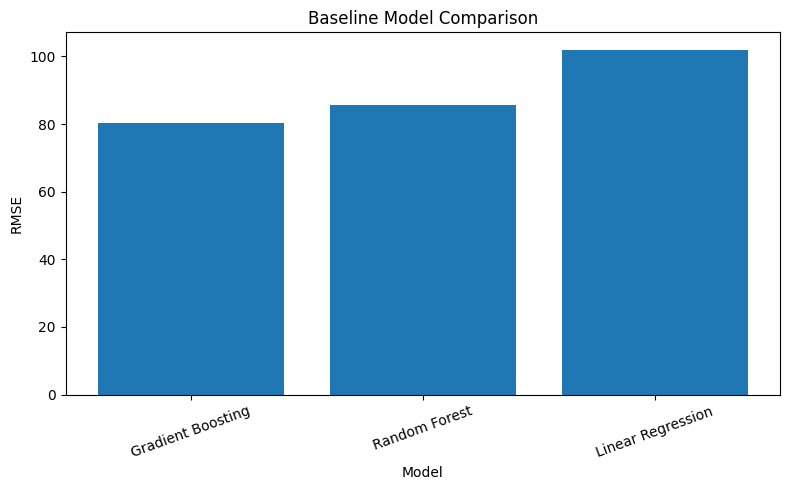

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    baseline_results["Model"],
    baseline_results["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Baseline Model Comparison")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_PATH,
        "baseline_model_comparison.png"
    )
)

plt.show()